In [1]:
# ============================================================
# F1 2026 Miami GP Prediction Project - STEP 1
# Google Colab Setup + Data Collection Starter Notebook
# Author: Ibrahim Khalil
# ============================================================

# Install required libraries
!pip install fastf1 pandas numpy matplotlib seaborn plotly scikit-learn -q

# ------------------------------------------------------------
# Imports
# ------------------------------------------------------------
import fastf1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import os

# Visualization settings
plt.style.use('dark_background')
sns.set(font_scale=1.1)
# Create cache directory first
os.makedirs('/content/cache', exist_ok=True)


# Enable FastF1 cache
fastf1.Cache.enable_cache('/content/cache')

print("Libraries loaded successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.4/135.4 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.2/70.2 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 40.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 7.0 MB/s eta 0:00:00
Libraries loaded successfully.


In [2]:
# ============================================================
# STEP 2 - Load 2026 Race Schedule
# ============================================================

schedule_2026 = fastf1.get_event_schedule(2026)

# Display race calendar
schedule_2026[['RoundNumber', 'EventName', 'Location', 'Country']]

,RoundNumber,EventName,Location,Country
0,0,Pre-Season Testing,Bahrain,Bahrain
1,0,Pre-Season Testing,Bahrain,Bahrain
2,1,Australian Grand Prix,Melbourne,Australia
3,2,Chinese Grand Prix,Shanghai,China
4,3,Japanese Grand Prix,Suzuka,Japan
5,4,Miami Grand Prix,Miami Gardens,United States
6,5,Canadian Grand Prix,Montréal,Canada
7,6,Monaco Grand Prix,Monte Carlo,Monaco
8,7,Barcelona Grand Prix,Barcelona,Spain
9,8,Austrian Grand Prix,Spielberg,Austria


In [3]:
# ============================================================
# STEP 3 - Show races before Miami GP
# ============================================================

# Find Miami round
miami_index = schedule_2026[schedule_2026['EventName'].str.contains('Miami', case=False)].index[0]

# All races before Miami
past_races = schedule_2026.loc[:miami_index-1]

past_races[['RoundNumber', 'EventName', 'Country']]

,RoundNumber,EventName,Country
0,0,Pre-Season Testing,Bahrain
1,0,Pre-Season Testing,Bahrain
2,1,Australian Grand Prix,Australia
3,2,Chinese Grand Prix,China
4,3,Japanese Grand Prix,Japan


In [4]:
# ============================================================
# STEP 4 - Collect Race Lap Data From All Previous Races
# ============================================================

all_laps = []

for _, row in past_races.iterrows():
    rnd = row['RoundNumber']
    race_name = row['EventName']

    try:
        print(f"Loading Round {rnd}: {race_name}")

        session = fastf1.get_session(2026, rnd, 'R')
        session.load()

        laps = session.laps.copy()
        laps['Race'] = race_name
        laps['Round'] = rnd

        all_laps.append(laps)

    except Exception as e:
        print(f"Skipped {race_name}: {e}")

# Combine all races
laps_df = pd.concat(all_laps, ignore_index=True)

print("Combined Shape:", laps_df.shape)
laps_df.head()

core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.2]
INFO:fastf1.fastf1.core:Loading data for Australian Grand Prix - Race [v3.8.2]
req            INFO 	No cached data found for session_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
INFO:fastf1.api:Fetching session info data...


Loading Round 0: Pre-Season Testing
Skipped Pre-Season Testing: Cannot get testing event by round number!
Loading Round 0: Pre-Season Testing
Skipped Pre-Season Testing: Cannot get testing event by round number!
Loading Round 1: Australian Grand Prix


req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
INFO:fastf1.api:Fetching driver list...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
INFO:fastf1.fastf1.req:No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
INFO:fastf1.api:Fetching session status data...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
INFO:fastf1.fastf1.req:No cached data found for lap_count. Loading data...
_api           INFO 	F

Loading Round 2: Chinese Grand Prix


req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
INFO:fastf1.fastf1.req:No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
INFO:fastf1.api:Fetching session status data...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
INFO:fastf1.fastf1.req:No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
INFO:fastf1.api:Fetching lap count data...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
INFO:fastf1.fastf1.req:No cached data found for track_status_data. Loading data...
_api

Loading Round 3: Japanese Grand Prix


req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
INFO:fastf1.api:Fetching driver list...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
INFO:fastf1.fastf1.req:No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
INFO:fastf1.api:Fetching session status data...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
INFO:fastf1.fastf1.req:No cached data found for lap_count. Loading data...
_api           INFO 	F

Combined Shape: (3038, 33)


,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate,Race,Round
0,0 days 01:03:56.437000,NOR,1,0 days 00:01:36.458000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:18.163000,...,0 days 01:02:19.743000,2026-03-08 04:03:26.366,1,6.0,False,,False,False,Australian Grand Prix,1
1,0 days 01:05:23.781000,NOR,1,0 days 00:01:27.344000,2.0,1.0,NaT,NaT,0 days 00:00:31.074000,0 days 00:00:18.116000,...,0 days 01:03:56.437000,2026-03-08 04:05:03.060,1,6.0,False,,False,True,Australian Grand Prix,1
2,0 days 01:06:50.644000,NOR,1,0 days 00:01:26.863000,3.0,1.0,NaT,NaT,0 days 00:00:30.541000,0 days 00:00:18.252000,...,0 days 01:05:23.781000,2026-03-08 04:06:30.404,1,7.0,False,,False,True,Australian Grand Prix,1
3,0 days 01:08:16.501000,NOR,1,0 days 00:01:25.857000,4.0,1.0,NaT,NaT,0 days 00:00:30.190000,0 days 00:00:18.193000,...,0 days 01:06:50.644000,2026-03-08 04:07:57.267,1,7.0,False,,False,True,Australian Grand Prix,1
4,0 days 01:09:42.074000,NOR,1,0 days 00:01:25.573000,5.0,1.0,NaT,NaT,0 days 00:00:29.930000,0 days 00:00:17.868000,...,0 days 01:08:16.501000,2026-03-08 04:09:23.124,1,7.0,False,,False,True,Australian Grand Prix,1


In [5]:
# ============================================================
# STEP 5 - Clean Main Columns
# ============================================================

df = laps_df[[
    'Race',
    'Round',
    'Driver',
    'Team',
    'LapNumber',
    'LapTime',
    'Stint',
    'Compound',
    'TyreLife',
    'Position'
]].copy()

# Convert lap time to seconds
df['LapTimeSeconds'] = df['LapTime'].dt.total_seconds()

# Remove invalid laps
df = df.dropna(subset=['LapTimeSeconds'])
df = df[df['LapTimeSeconds'] < 200]

df.head()

,Race,Round,Driver,Team,LapNumber,LapTime,Stint,Compound,TyreLife,Position,LapTimeSeconds
0,Australian Grand Prix,1,NOR,McLaren,1.0,0 days 00:01:36.458000,1.0,MEDIUM,1.0,6.0,96.458
1,Australian Grand Prix,1,NOR,McLaren,2.0,0 days 00:01:27.344000,1.0,MEDIUM,2.0,6.0,87.344
2,Australian Grand Prix,1,NOR,McLaren,3.0,0 days 00:01:26.863000,1.0,MEDIUM,3.0,7.0,86.863
3,Australian Grand Prix,1,NOR,McLaren,4.0,0 days 00:01:25.857000,1.0,MEDIUM,4.0,7.0,85.857
4,Australian Grand Prix,1,NOR,McLaren,5.0,0 days 00:01:25.573000,1.0,MEDIUM,5.0,7.0,85.573


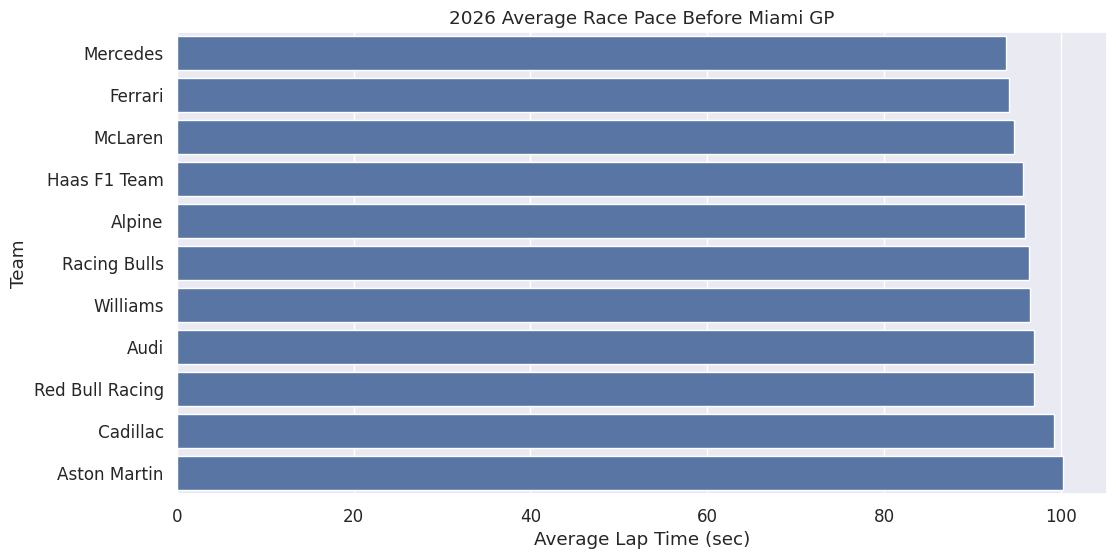

In [6]:
# ============================================================
# STEP 6 - Initial EDA
# Average Race Pace by Team
# ============================================================

team_pace = df.groupby('Team')['LapTimeSeconds'].mean().sort_values()

plt.figure(figsize=(12,6))
sns.barplot(x=team_pace.values, y=team_pace.index)
plt.title("2026 Average Race Pace Before Miami GP")
plt.xlabel("Average Lap Time (sec)")
plt.show()

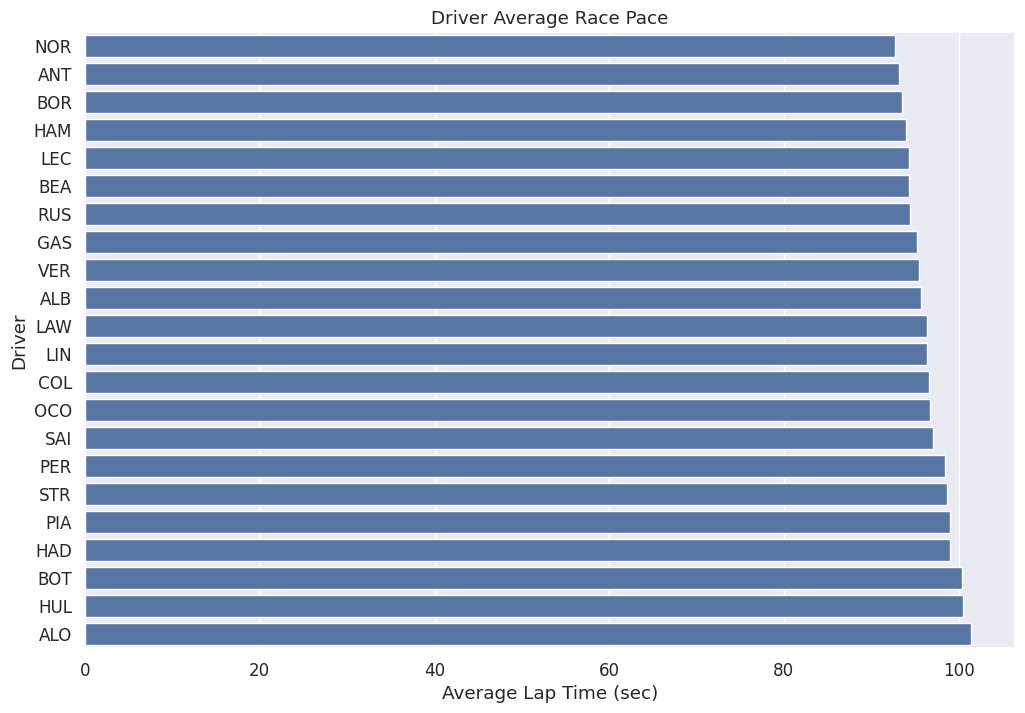

In [7]:
# ============================================================
# STEP 7 - Driver Pace Ranking
# ============================================================

driver_pace = df.groupby('Driver')['LapTimeSeconds'].mean().sort_values()

plt.figure(figsize=(12,8))
sns.barplot(x=driver_pace.values, y=driver_pace.index)
plt.title("Driver Average Race Pace")
plt.xlabel("Average Lap Time (sec)")
plt.show()

In [8]:
# ============================================================
# STEP 8 - Save Dataset
# ============================================================

df.to_csv('/content/f1_2026_pre_miami_dataset.csv', index=False)

print("Dataset saved successfully.")

Dataset saved successfully.


In [9]:


plt.style.use("dark_background")
sns.set(font_scale=1.1)

df = pd.read_csv('/content/f1_2026_pre_miami_dataset.csv')

print(df.shape)
df.head()

(2990, 11)


,Race,Round,Driver,Team,LapNumber,LapTime,Stint,Compound,TyreLife,Position,LapTimeSeconds
0,Australian Grand Prix,1,NOR,McLaren,1.0,0 days 00:01:36.458000,1.0,MEDIUM,1.0,6.0,96.458
1,Australian Grand Prix,1,NOR,McLaren,2.0,0 days 00:01:27.344000,1.0,MEDIUM,2.0,6.0,87.344
2,Australian Grand Prix,1,NOR,McLaren,3.0,0 days 00:01:26.863000,1.0,MEDIUM,3.0,7.0,86.863
3,Australian Grand Prix,1,NOR,McLaren,4.0,0 days 00:01:25.857000,1.0,MEDIUM,4.0,7.0,85.857
4,Australian Grand Prix,1,NOR,McLaren,5.0,0 days 00:01:25.573000,1.0,MEDIUM,5.0,7.0,85.573


In [10]:
print(df.info())
print(df.describe(include='all'))
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2990 entries, 0 to 2989
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Race            2990 non-null   object 
 1   Round           2990 non-null   int64  
 2   Driver          2990 non-null   object 
 3   Team            2990 non-null   object 
 4   LapNumber       2990 non-null   float64
 5   LapTime         2990 non-null   object 
 6   Stint           2990 non-null   float64
 7   Compound        2990 non-null   object 
 8   TyreLife        2990 non-null   float64
 9   Position        2990 non-null   float64
 10  LapTimeSeconds  2990 non-null   float64
dtypes: float64(5), int64(1), object(5)
memory usage: 257.1+ KB
None
                       Race        Round Driver          Team    LapNumber  \
count                  2990  2990.000000   2990          2990  2990.000000   
unique                    3          NaN     22            11          NaN   
top  

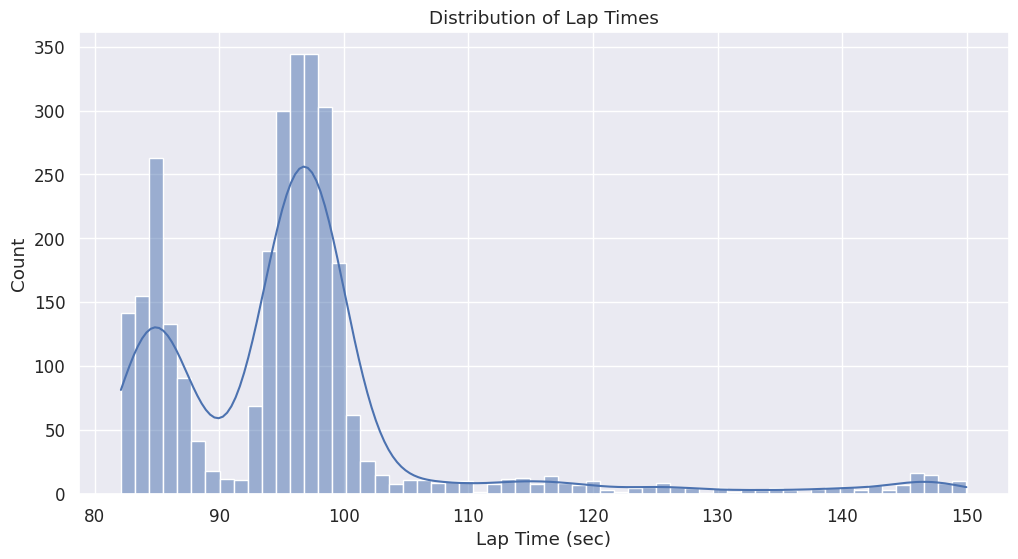

In [11]:
plt.figure(figsize=(12,6))
sns.histplot(df['LapTimeSeconds'], bins=60, kde=True)
plt.title("Distribution of Lap Times")
plt.xlabel("Lap Time (sec)")
plt.show()

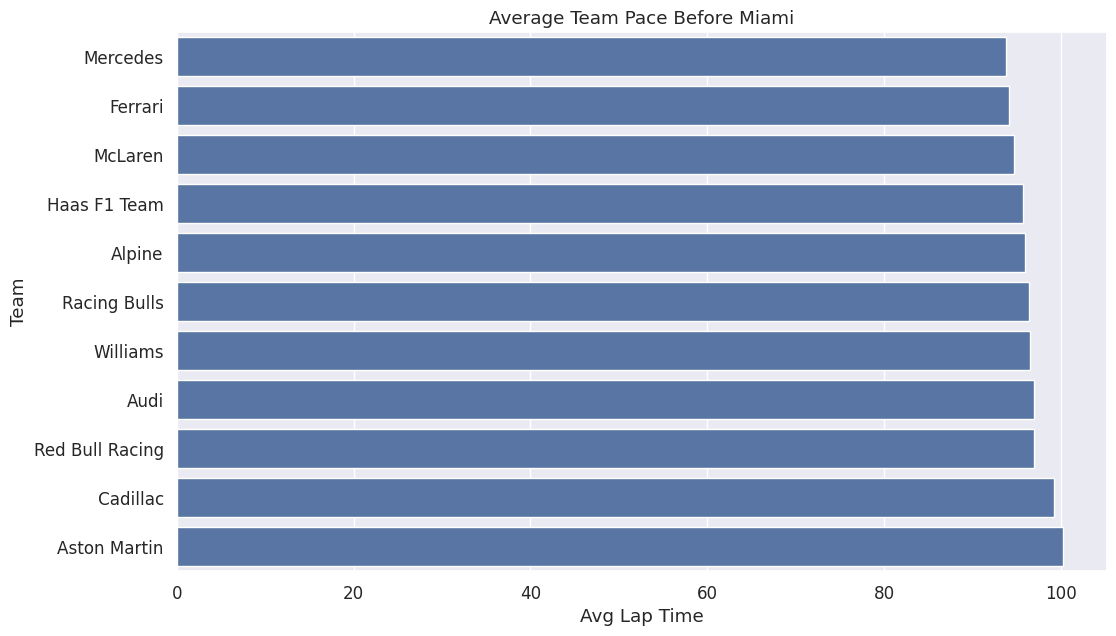

In [12]:
team_pace = df.groupby('Team')['LapTimeSeconds'].mean().sort_values()

plt.figure(figsize=(12,7))
sns.barplot(x=team_pace.values, y=team_pace.index)
plt.title("Average Team Pace Before Miami")
plt.xlabel("Avg Lap Time")
plt.show()

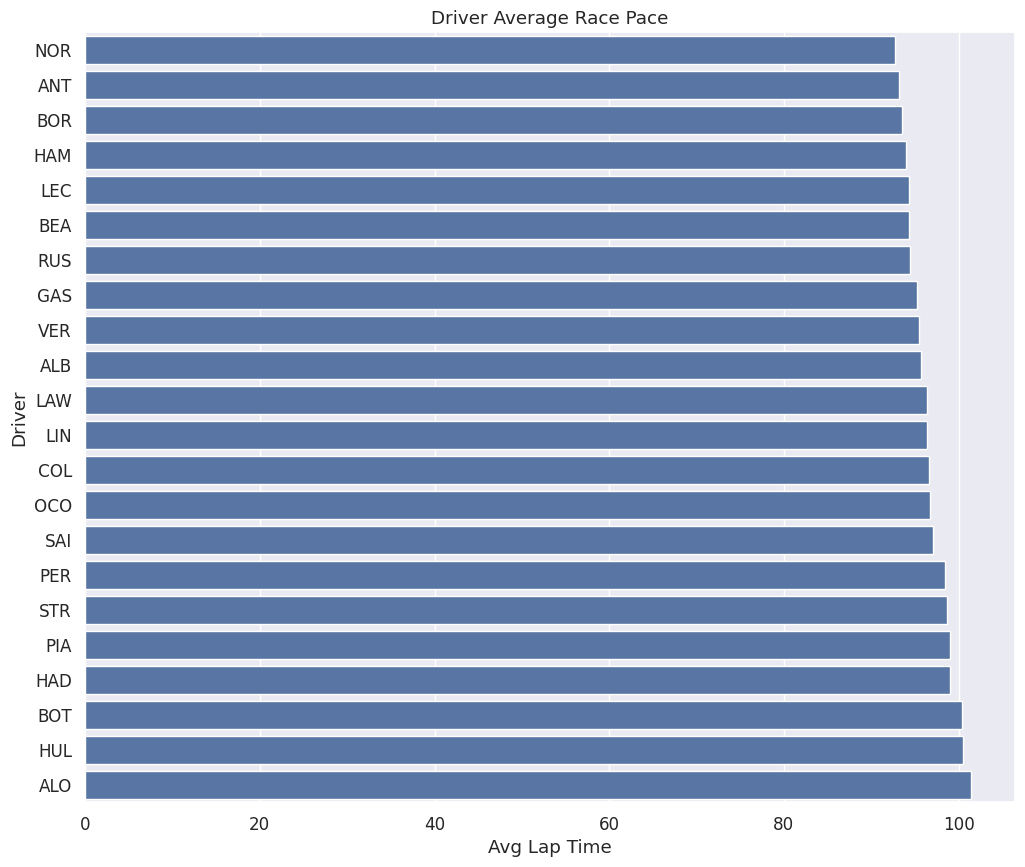

In [13]:
driver_pace = df.groupby('Driver')['LapTimeSeconds'].mean().sort_values()

plt.figure(figsize=(12,10))
sns.barplot(x=driver_pace.values, y=driver_pace.index)
plt.title("Driver Average Race Pace")
plt.xlabel("Avg Lap Time")
plt.show()

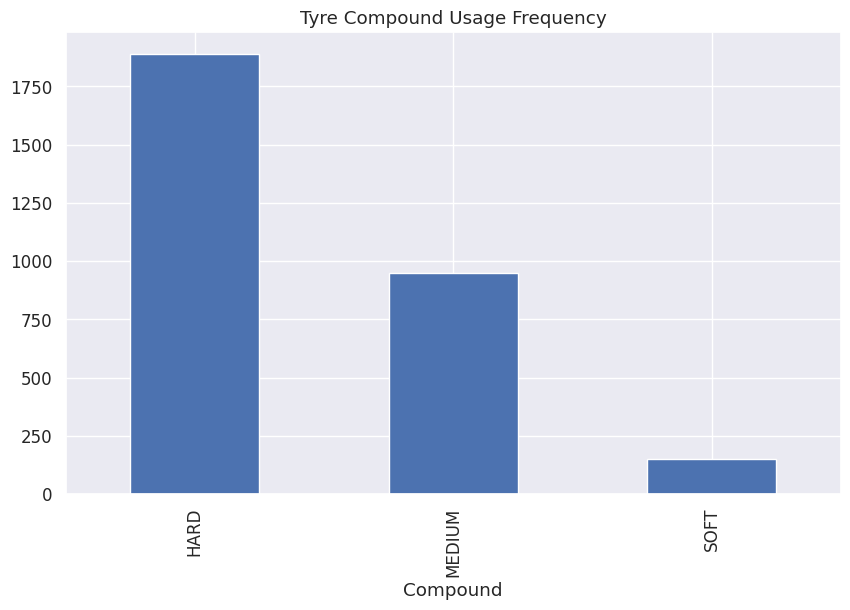

In [14]:
plt.figure(figsize=(10,6))
df['Compound'].value_counts().plot(kind='bar')
plt.title("Tyre Compound Usage Frequency")
plt.show()

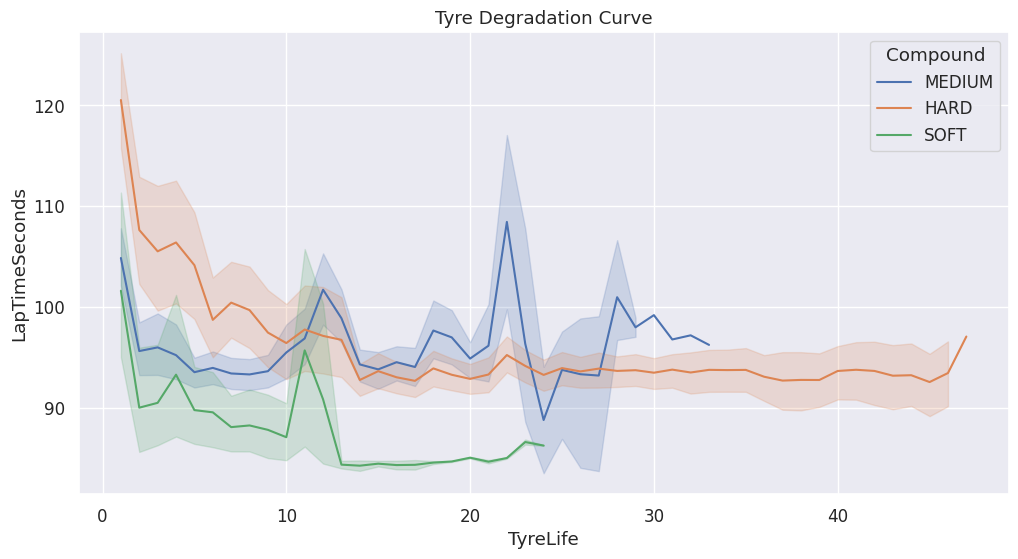

In [15]:
sample = df[df['Compound'].isin(['SOFT','MEDIUM','HARD'])]

plt.figure(figsize=(12,6))
sns.lineplot(data=sample, x='TyreLife', y='LapTimeSeconds', hue='Compound')
plt.title("Tyre Degradation Curve")
plt.show()

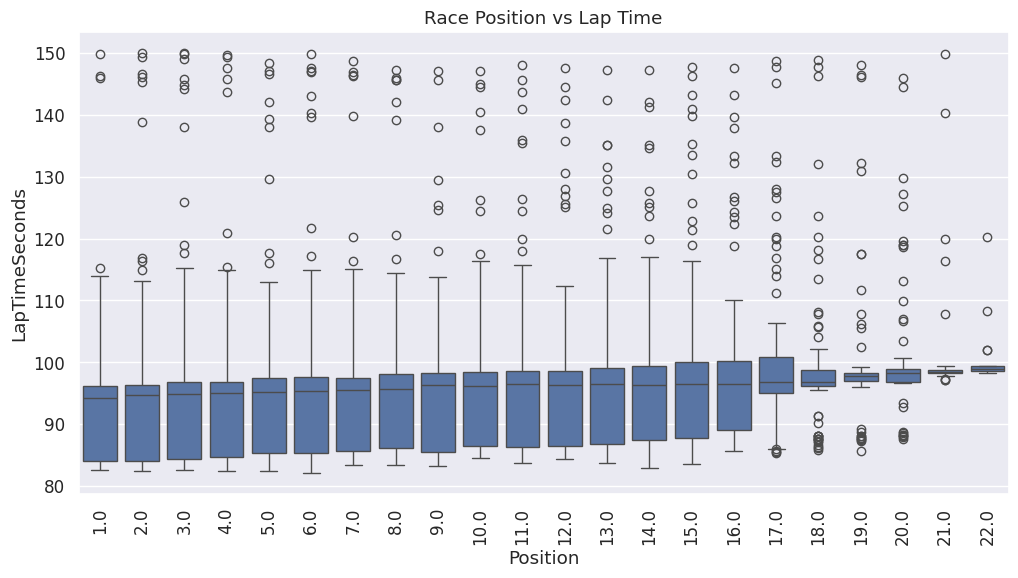

In [16]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='Position', y='LapTimeSeconds')
plt.title("Race Position vs Lap Time")
plt.xticks(rotation=90)
plt.show()

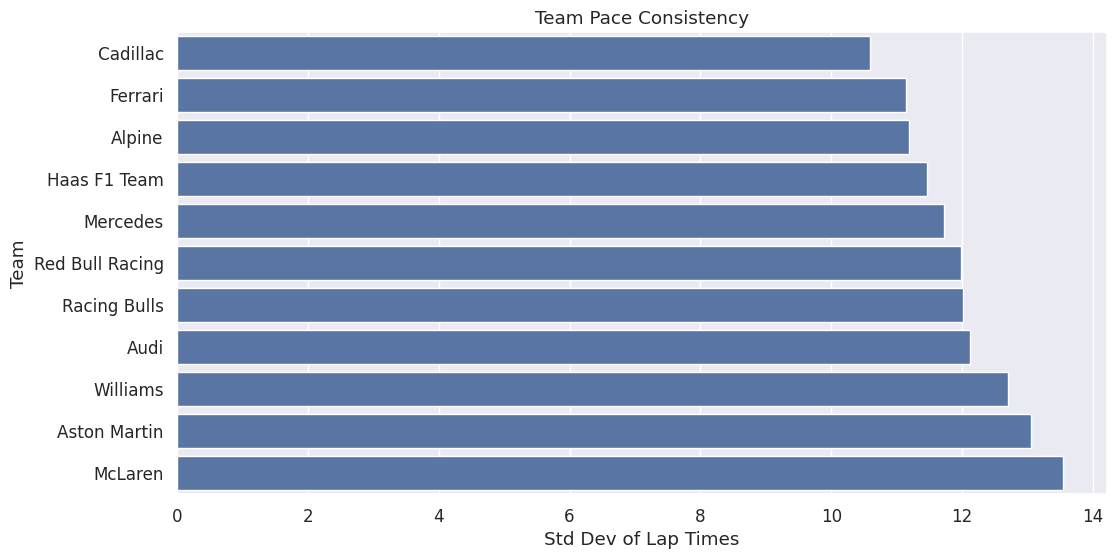

In [17]:
consistency = df.groupby('Team')['LapTimeSeconds'].std().sort_values()

plt.figure(figsize=(12,6))
sns.barplot(x=consistency.values, y=consistency.index)
plt.title("Team Pace Consistency")
plt.xlabel("Std Dev of Lap Times")
plt.show()

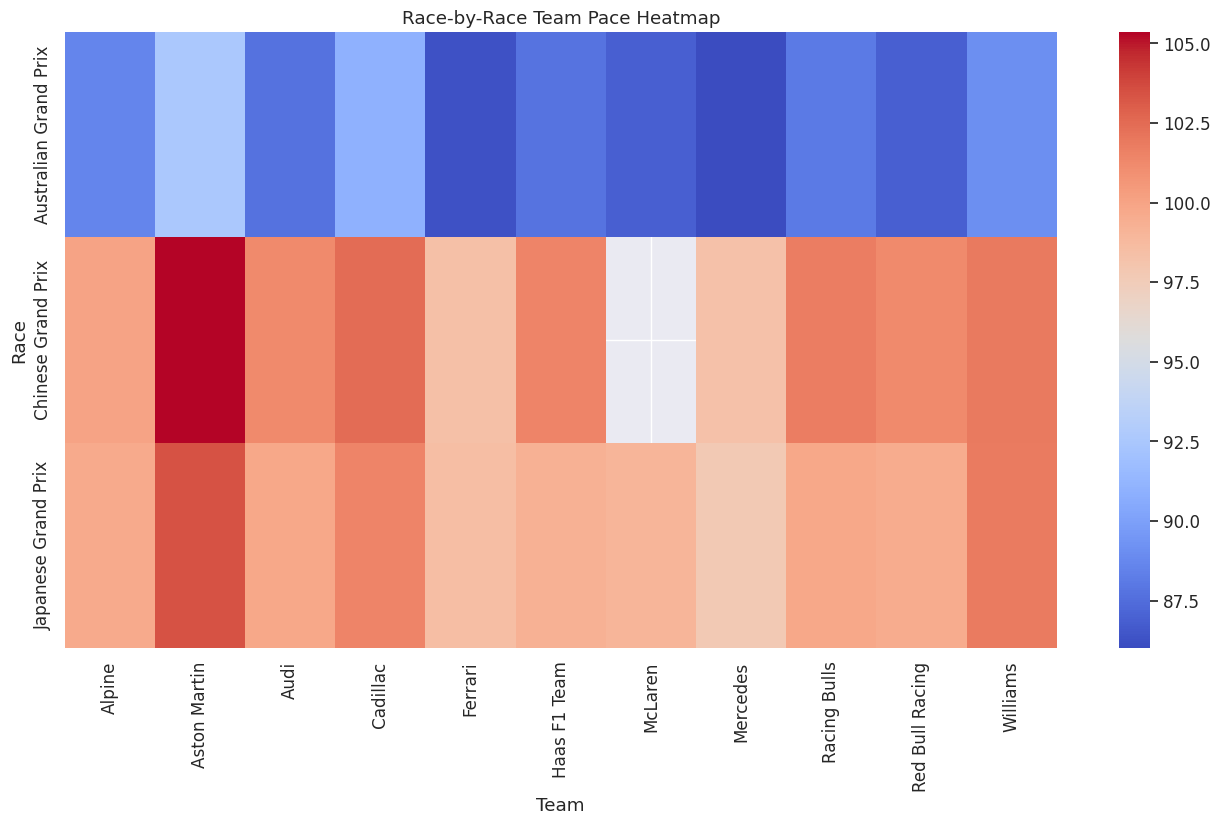

In [18]:
pivot = df.pivot_table(
    values='LapTimeSeconds',
    index='Race',
    columns='Team',
    aggfunc='mean'
)

plt.figure(figsize=(16,8))
sns.heatmap(pivot, cmap='coolwarm', annot=False)
plt.title("Race-by-Race Team Pace Heatmap")
plt.show()

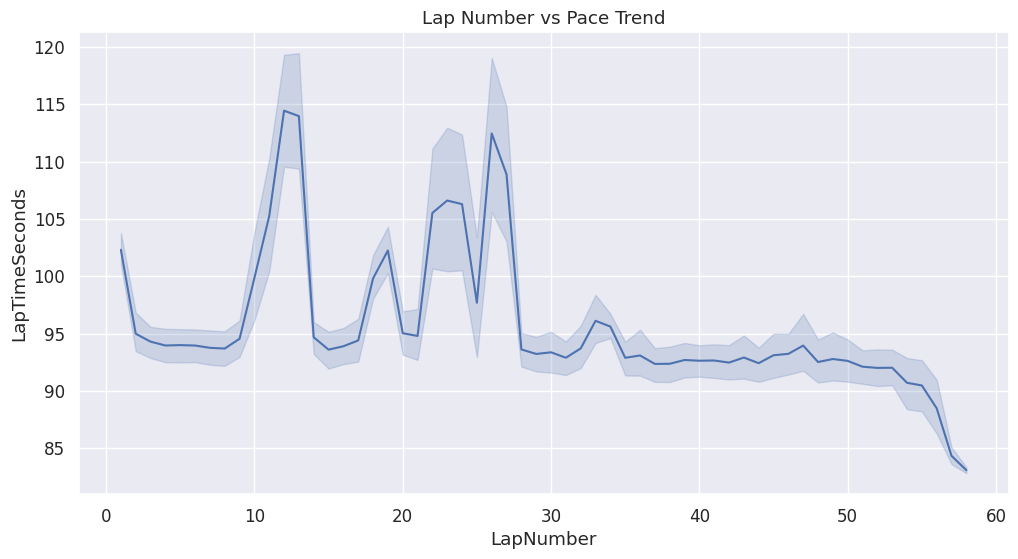

In [19]:
plt.figure(figsize=(12,6))
sns.lineplot(data=df, x='LapNumber', y='LapTimeSeconds')
plt.title("Lap Number vs Pace Trend")
plt.show()

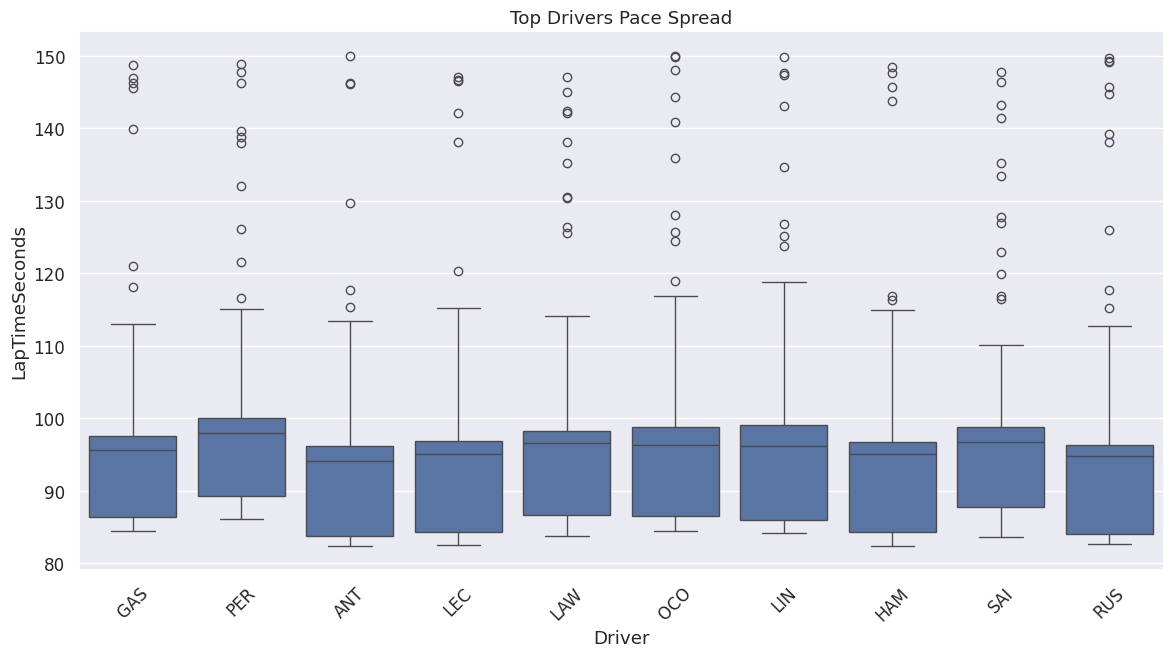

In [20]:
top_drivers = df['Driver'].value_counts().head(10).index
subset = df[df['Driver'].isin(top_drivers)]

plt.figure(figsize=(14,7))
sns.boxplot(data=subset, x='Driver', y='LapTimeSeconds')
plt.title("Top Drivers Pace Spread")
plt.xticks(rotation=45)
plt.show()

In [21]:
fig = px.scatter(
    df.sample(min(3000, len(df))),
    x="TyreLife",
    y="LapTimeSeconds",
    color="Team",
    hover_data=["Driver","Race"]
)
fig.show()

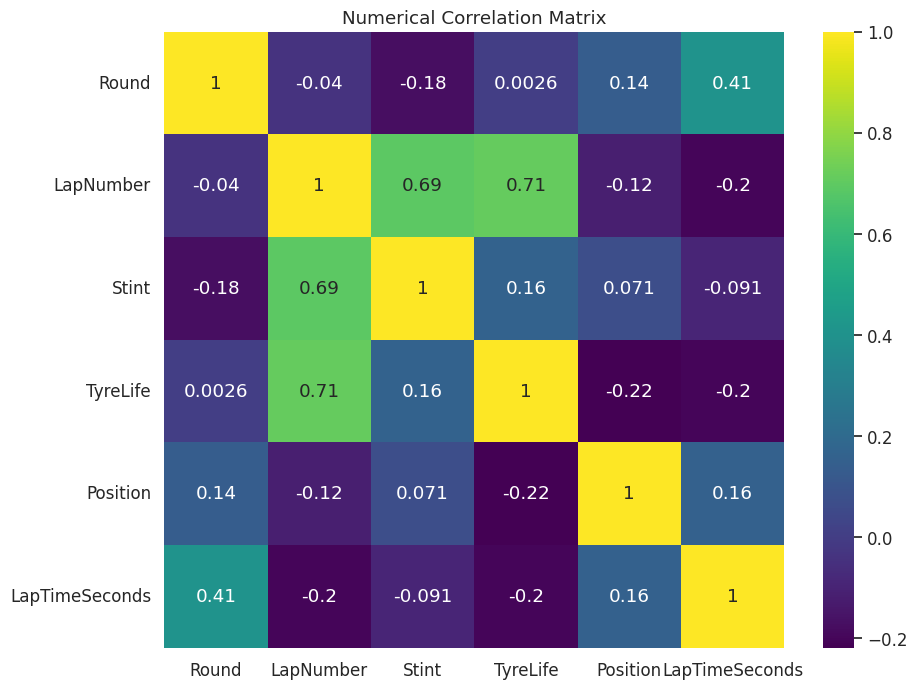

In [22]:
num_cols = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,8))
sns.heatmap(num_cols.corr(), annot=True, cmap='viridis')
plt.title("Numerical Correlation Matrix")
plt.show()

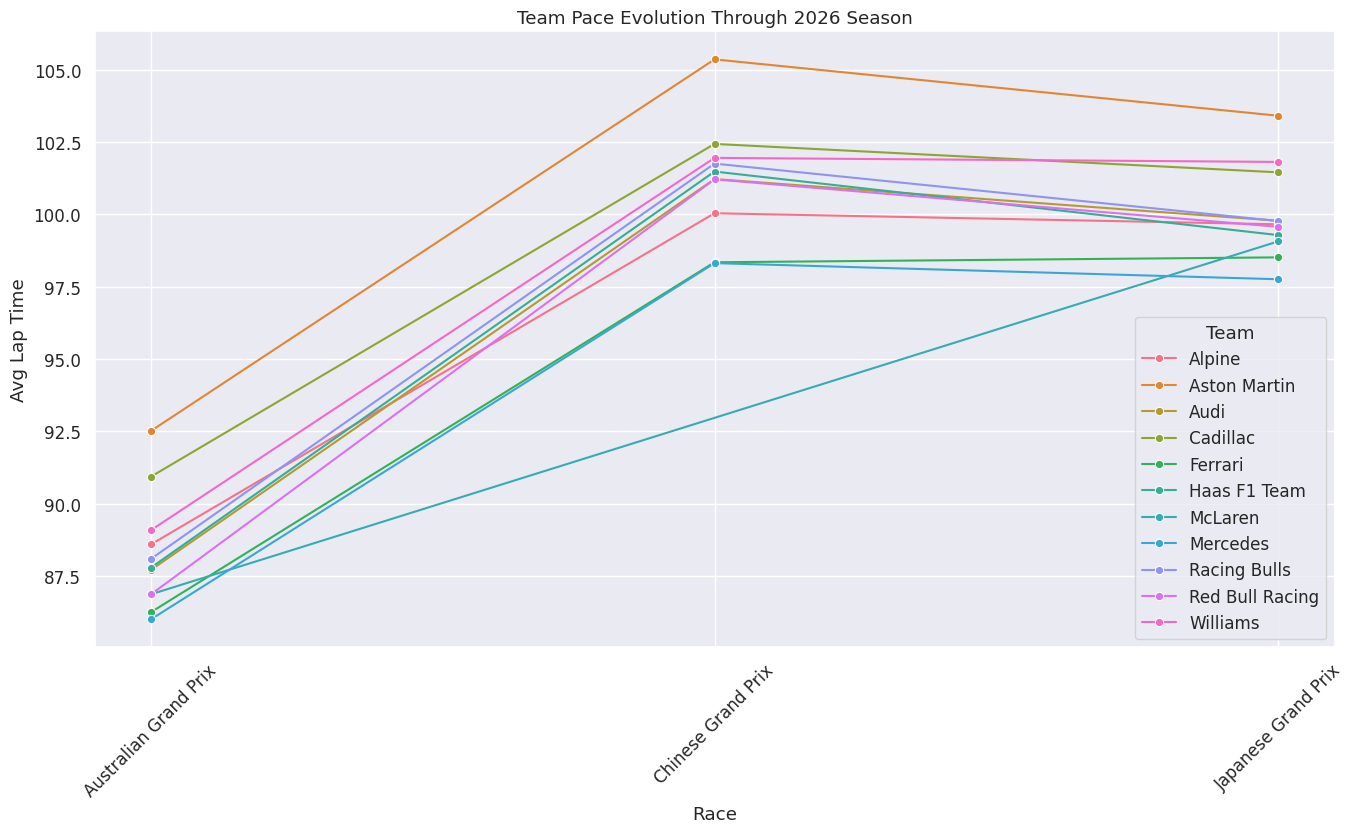

In [23]:
team_race = df.groupby(['Race','Team'])['LapTimeSeconds'].mean().reset_index()

plt.figure(figsize=(16,8))
sns.lineplot(data=team_race, x='Race', y='LapTimeSeconds', hue='Team', marker='o')
plt.title("Team Pace Evolution Through 2026 Season")
plt.xticks(rotation=45)
plt.ylabel("Avg Lap Time")
plt.show()

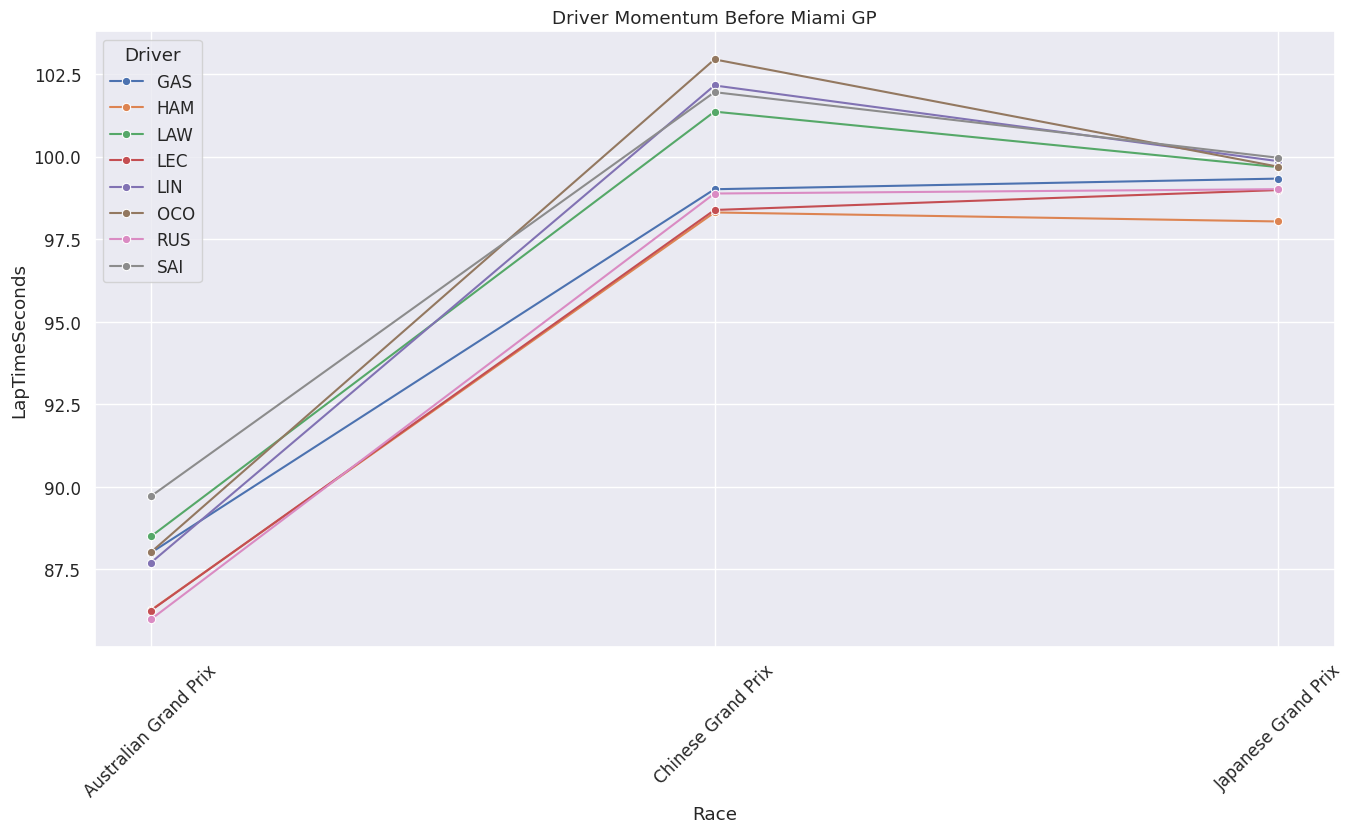

In [24]:
driver_race = df.groupby(['Race','Driver'])['LapTimeSeconds'].mean().reset_index()

top_drivers = df['Driver'].value_counts().head(8).index
subset = driver_race[driver_race['Driver'].isin(top_drivers)]

plt.figure(figsize=(16,8))
sns.lineplot(data=subset, x='Race', y='LapTimeSeconds', hue='Driver', marker='o')
plt.title("Driver Momentum Before Miami GP")
plt.xticks(rotation=45)
plt.show()

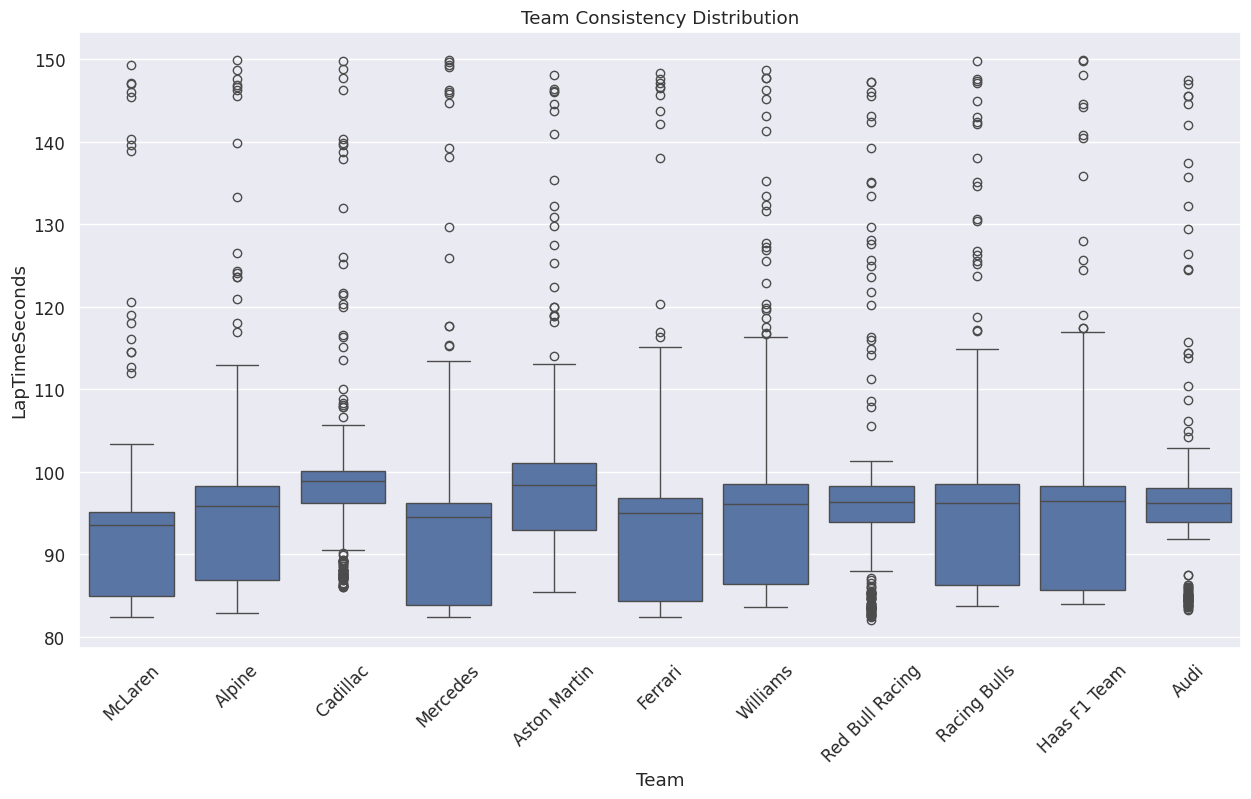

In [25]:
plt.figure(figsize=(15,8))
sns.boxplot(data=df, x='Team', y='LapTimeSeconds')
plt.xticks(rotation=45)
plt.title("Team Consistency Distribution")
plt.show()

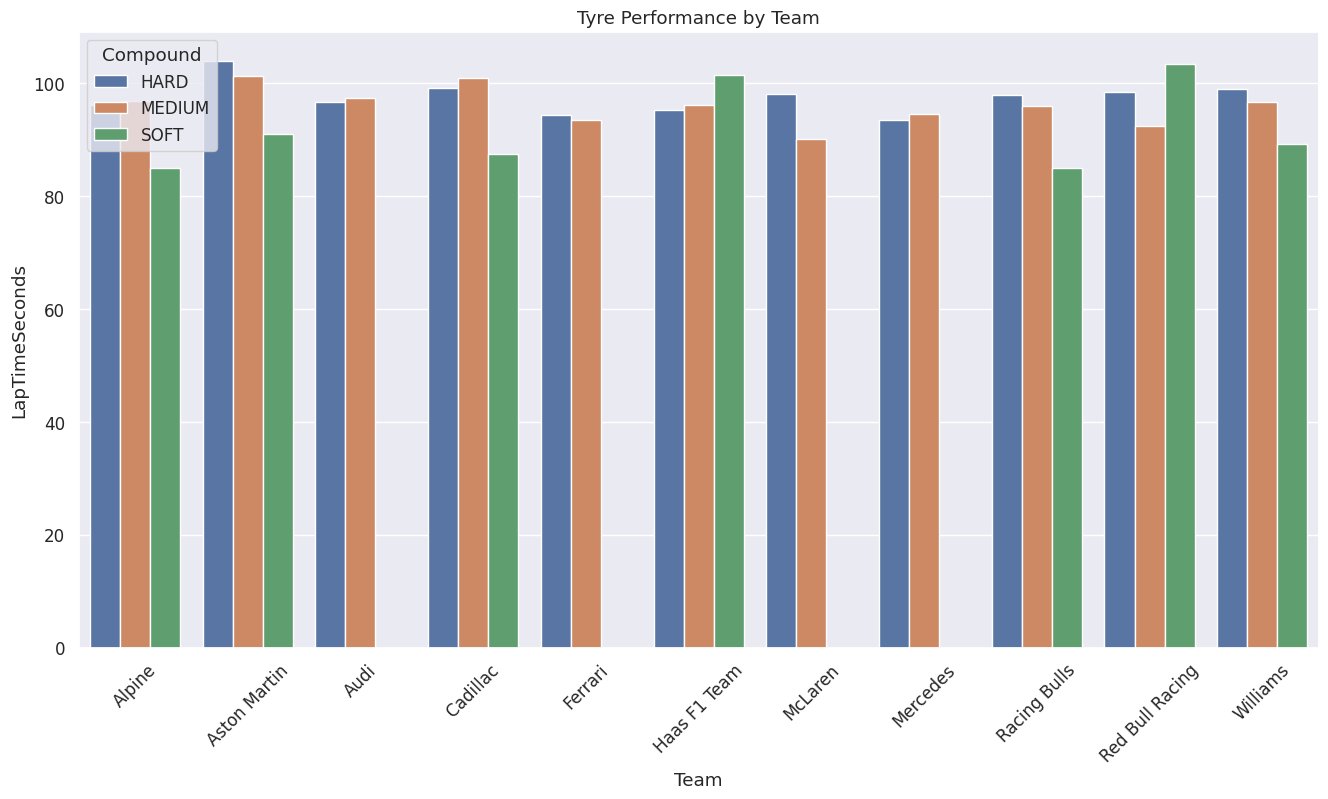

In [26]:
compound_team = df.groupby(['Team','Compound'])['LapTimeSeconds'].mean().reset_index()

plt.figure(figsize=(16,8))
sns.barplot(data=compound_team, x='Team', y='LapTimeSeconds', hue='Compound')
plt.xticks(rotation=45)
plt.title("Tyre Performance by Team")
plt.show()

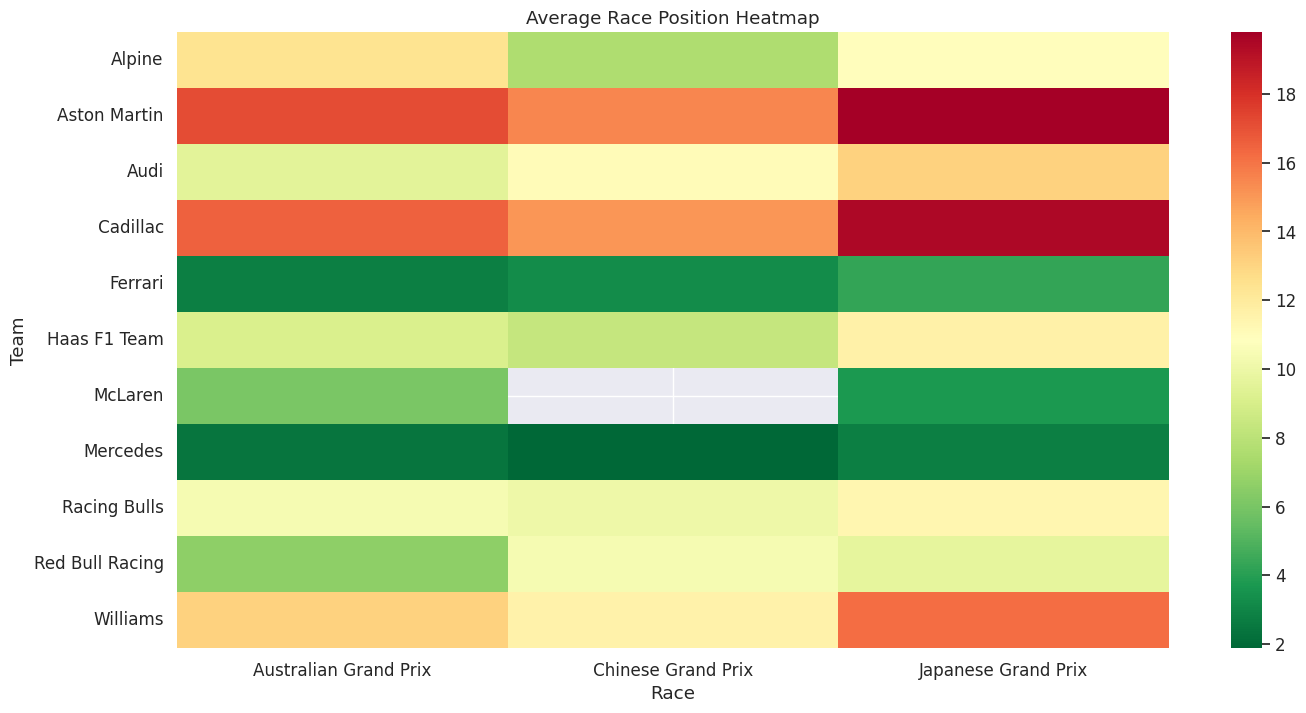

In [27]:
pos = df.pivot_table(values='Position', index='Team', columns='Race', aggfunc='mean')

plt.figure(figsize=(16,8))
sns.heatmap(pos, cmap='RdYlGn_r', annot=False)
plt.title("Average Race Position Heatmap")
plt.show()
#Lower numbers = greener = stronger.

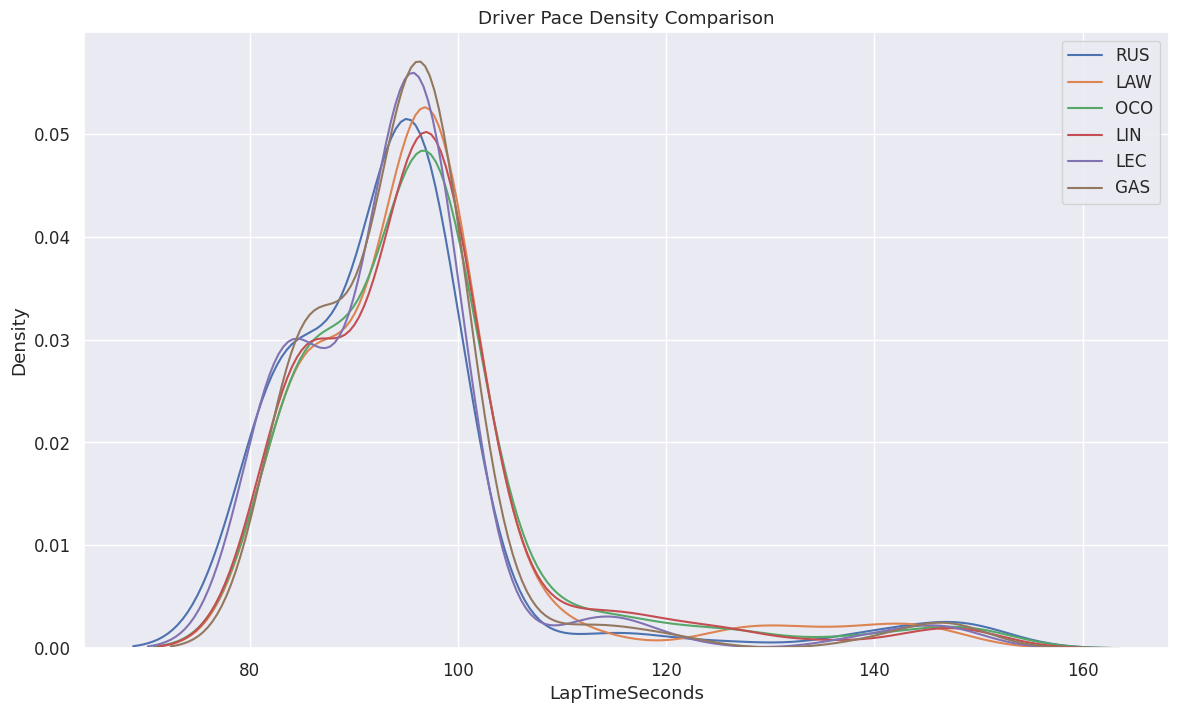

In [28]:
top_drivers = df['Driver'].value_counts().head(6).index

plt.figure(figsize=(14,8))
for d in top_drivers:
    sns.kdeplot(df[df['Driver']==d]['LapTimeSeconds'], label=d)

plt.title("Driver Pace Density Comparison")
plt.legend()
plt.show()

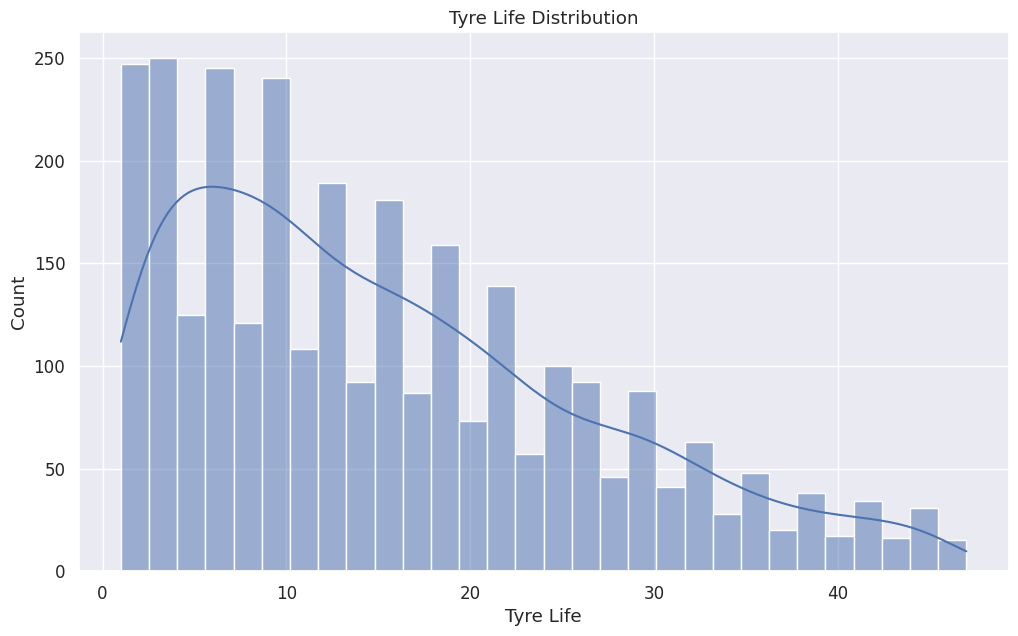

In [29]:
plt.figure(figsize=(12,7))
sns.histplot(df['TyreLife'], bins=30, kde=True)
plt.title("Tyre Life Distribution")
plt.xlabel("Tyre Life")
plt.show()

In [34]:
import plotly.graph_objects as go
import pandas as pd

# Aggregate metrics
metrics = df.groupby('Team').agg({
    'LapTimeSeconds': 'mean',
    'Position': 'mean',
    'TyreLife': 'mean'
}).reset_index()

# Select only desired teams
target_teams = ['Mercedes', 'Ferrari', 'Red Bull Racing', 'McLaren']

filtered = metrics[metrics['Team'].isin(target_teams)].copy()

fig = go.Figure()

# Add one radar trace per team
for _, team in filtered.iterrows():
    fig.add_trace(go.Scatterpolar(
        r=[
            team['LapTimeSeconds'],
            team['Position'],
            team['TyreLife']
        ],
        theta=[
            'Pace',
            'Position',
            'Tyre Life'
        ],
        fill='toself',
        name=team['Team']
    ))

fig.update_layout(
    polar=dict(
        radialaxis=dict(
            visible=True
        )
    ),
    title="Top Teams Radar Comparison",
    showlegend=True,
    template="plotly_dark"
)

fig.show()

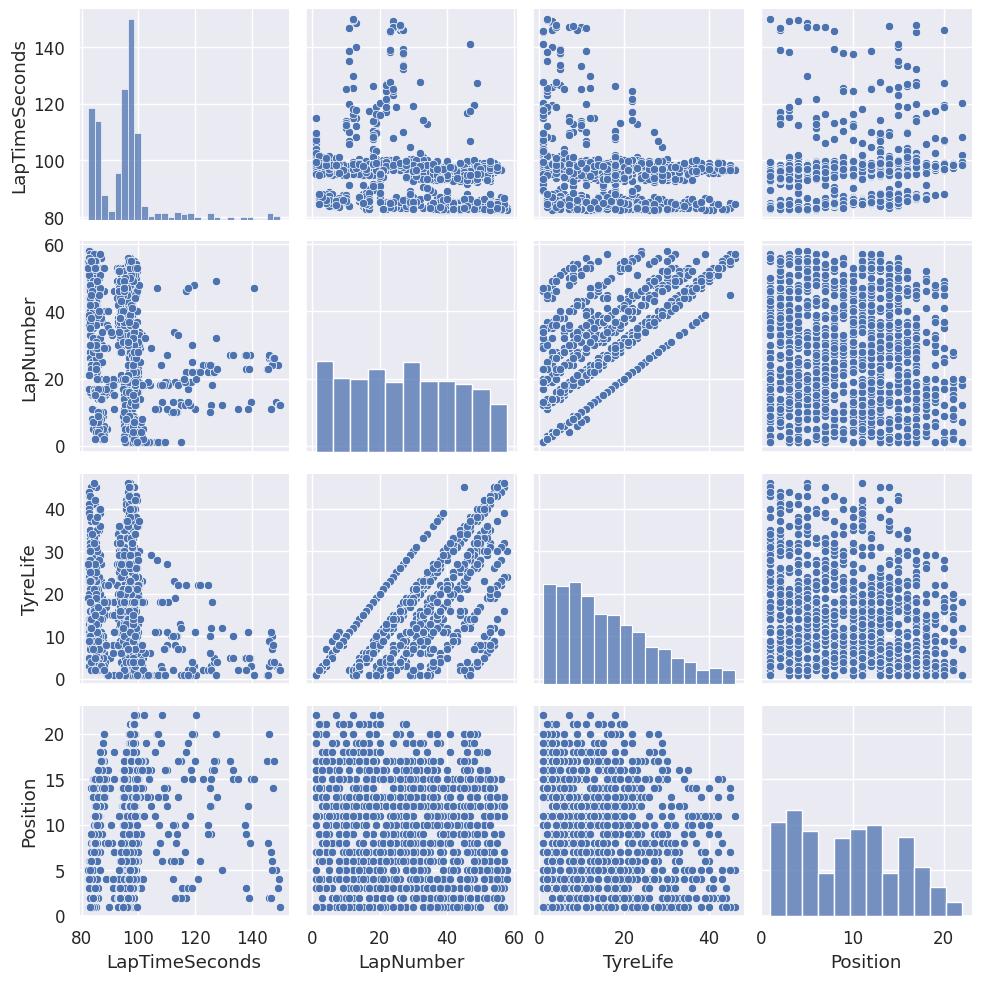

In [32]:
sample = df[['LapTimeSeconds','LapNumber','TyreLife','Position']].dropna().sample(min(1000,len(df)))
sns.pairplot(sample)
plt.show()

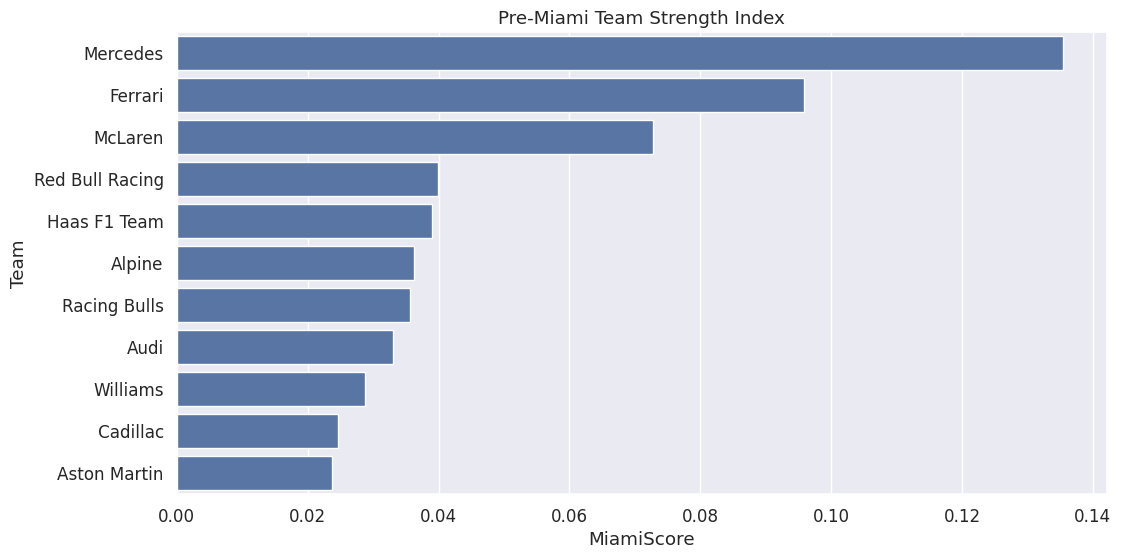

In [33]:
rank = df.groupby('Team').agg({
    'LapTimeSeconds':'mean',
    'Position':'mean'
})

rank['MiamiScore'] = (
    (1/rank['LapTimeSeconds'])*0.7 +
    (1/rank['Position'])*0.3
)

rank = rank.sort_values('MiamiScore', ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(x=rank['MiamiScore'], y=rank.index)
plt.title("Pre-Miami Team Strength Index")
plt.show()

In [41]:
focus_teams = ['Mercedes', 'Ferrari', 'McLaren', 'Red Bull Racing', 'Haas F1 Team']

df_focus = df[df['Team'].isin(focus_teams)].copy()

print(df_focus['Team'].unique())
print(df_focus.shape)

['McLaren' 'Mercedes' 'Ferrari' 'Red Bull Racing' 'Haas F1 Team']
(1383, 11)


In [42]:
driver_race = df_focus.groupby(['Race','Driver','Team']).agg({
    'Position':'mean',
    'LapTimeSeconds':'mean',
    'LapNumber':'max',
    'TyreLife':'mean'
}).reset_index()

driver_race.head()

,Race,Driver,Team,Position,LapTimeSeconds,LapNumber,TyreLife
0,Australian Grand Prix,ANT,Mercedes,3.137931,86.030603,58.0,19.982759
1,Australian Grand Prix,BEA,Haas F1 Team,8.070175,87.568316,57.0,16.684211
2,Australian Grand Prix,HAD,Red Bull Racing,4.500000,86.552500,10.0,5.500000
3,Australian Grand Prix,HAM,Ferrari,3.206897,86.257672,58.0,15.017241
4,Australian Grand Prix,LEC,Ferrari,2.241379,86.246897,58.0,15.275862


In [43]:
driver_race = driver_race.sort_values(['Driver','Race'])

driver_race['PrevFinish'] = driver_race.groupby('Driver')['Position'].shift(1)
driver_race['PrevPace'] = driver_race.groupby('Driver')['LapTimeSeconds'].shift(1)

driver_race['RecentFinish3'] = driver_race.groupby('Driver')['Position'].rolling(3).mean().reset_index(0,drop=True)

driver_race['Podium'] = (driver_race['Position'] <= 3).astype(int)

driver_race = driver_race.dropna()

In [48]:
# ==========================================================
# FIXED VERSION (handles class imbalance issue)
# ==========================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2
import tensorflow as tf
import pandas as pd
import numpy as np

# ----------------------------------------------------------
# Reproducibility
# ----------------------------------------------------------
np.random.seed(42)
tf.random.set_seed(42)

# ----------------------------------------------------------
# Encode Team
# ----------------------------------------------------------
le = LabelEncoder()
driver_race['TeamEnc'] = le.fit_transform(driver_race['Team'])

# ----------------------------------------------------------
# Features / Target
# ----------------------------------------------------------
X = driver_race[
    ['PrevFinish', 'PrevPace', 'RecentFinish3', 'TyreLife', 'TeamEnc']
].copy()

y = driver_race['Podium'].astype(int)

# ----------------------------------------------------------
# Check class counts
# ----------------------------------------------------------
print("Class distribution:")
print(y.value_counts())

# ----------------------------------------------------------
# If minority class too small, use normal split
# ----------------------------------------------------------
use_stratify = y.value_counts().min() >= 2

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y if use_stratify else None
)

# ----------------------------------------------------------
# Scale AFTER split
# ----------------------------------------------------------
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ----------------------------------------------------------
# Model
# ----------------------------------------------------------
model = Sequential([
    Dense(32, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.30),

    Dense(16, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.20),

    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# ----------------------------------------------------------
# Early Stopping
# ----------------------------------------------------------
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

# ----------------------------------------------------------
# Train
# ----------------------------------------------------------
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=8,
    callbacks=[early_stop],
    verbose=1
)

# ----------------------------------------------------------
# Evaluate
# ----------------------------------------------------------
loss, acc = model.evaluate(X_test, y_test, verbose=0)

print(f"\nTest Accuracy: {acc:.3f}")
print(f"Test Loss: {loss:.3f}")

Class distribution:
Podium
0    7
1    1
Name: count, dtype: int64
Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.6667 - loss: 0.6872 - val_accuracy: 1.0000 - val_loss: 0.4518
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step - accuracy: 0.6667 - loss: 0.6755 - val_accuracy: 1.0000 - val_loss: 0.4367
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 272ms/step - accuracy: 0.3333 - loss: 0.7878 - val_accuracy: 1.0000 - val_loss: 0.4229
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step - accuracy: 0.5000 - loss: 0.7790 - val_accuracy: 1.0000 - val_loss: 0.4097
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step - accuracy: 0.5000 - loss: 0.6939 - val_accuracy: 1.0000 - val_loss: 0.3971
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 318ms/step - accuracy: 0.8333 - loss: 0.6602 - val_accuracy: 1.0000 - val_loss: 0.3853
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step - accuracy: 0.5000 - loss: 0.7515 - val_accuracy: 1.0000 - val_loss: 0.3736
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 342ms/s

In [49]:
latest = driver_race.groupby('Driver').tail(1).copy()

X_miami = latest[
    ['PrevFinish','PrevPace','RecentFinish3','TyreLife','TeamEnc']
]

X_miami_scaled = scaler.transform(X_miami)

latest['PodiumProb'] = model.predict(X_miami_scaled)

latest[['Driver','Team','PodiumProb']].sort_values(
    'PodiumProb',
    ascending=False
).head(10)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


,Driver,Team,PodiumProb
17,ANT,Mercedes,0.475791
25,RUS,Mercedes,0.337891
21,LEC,Ferrari,0.231755
20,HAM,Ferrari,0.208803
19,HAD,Red Bull Racing,0.113239
23,OCO,Haas F1 Team,0.065971
26,VER,Red Bull Racing,0.056869
18,BEA,Haas F1 Team,0.000014


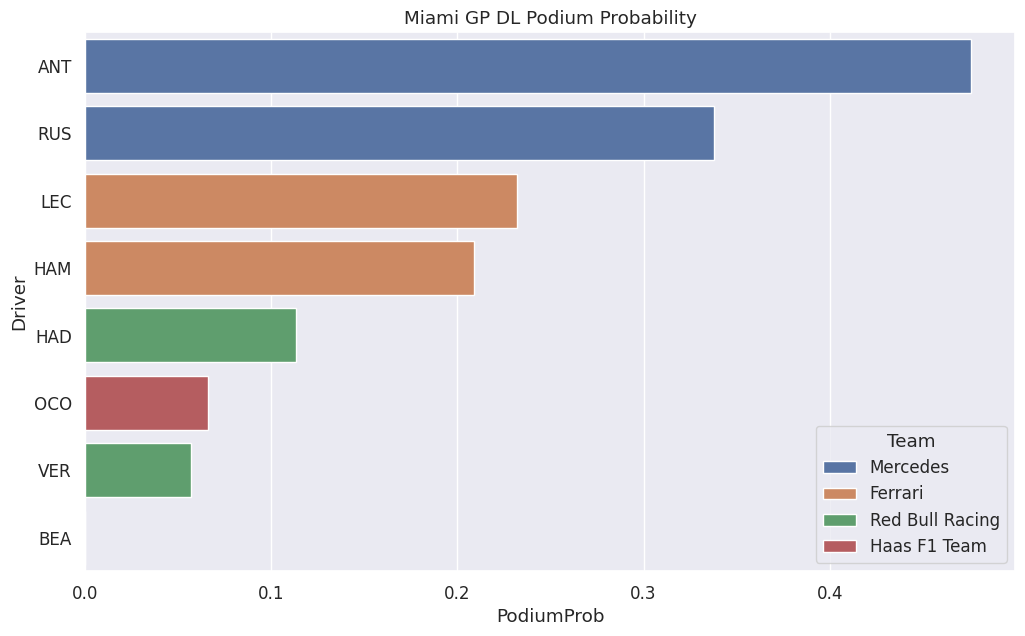

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

pred = latest.sort_values('PodiumProb', ascending=False)

plt.figure(figsize=(12,7))
sns.barplot(data=pred, x='PodiumProb', y='Driver', hue='Team')
plt.title("Miami GP DL Podium Probability")
plt.show()